In [ ]:
import sys
import os

ROOT_DIR = "/path/to/your/project"  # change this to your actual project path
chembart_path = os.path.join(ROOT_DIR, "model")

if chembart_path not in sys.path:
    sys.path.insert(0, chembart_path)

# temperature & yield

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def aggregate_data(df, interval):
    # 计算新的行和列索引
    new_row_indices = df.index[::interval]
    new_col_indices = df.columns[::interval]
    
    # 创建一个新的 DataFrame 来存储聚合后的数据
    aggregated_df = pd.DataFrame(index=new_row_indices, columns=new_col_indices)
    
    for i in range(len(new_row_indices) - 1):
        for j in range(len(new_col_indices) - 1):
            # 获取当前块的数据
            block = df.loc[new_row_indices[i]:new_row_indices[i+1], new_col_indices[j]:new_col_indices[j+1]]
            # 计算块的总和
            aggregated_df.loc[new_row_indices[i], new_col_indices[j]] = block.sum().sum()
    
    # 处理最后一行和最后一列
    for j in range(len(new_col_indices) - 1):
        block = df.loc[new_row_indices[-1]:, new_col_indices[j]:new_col_indices[j+1]]
        aggregated_df.loc[new_row_indices[-1], new_col_indices[j]] = block.sum().sum()
    
    for i in range(len(new_row_indices) - 1):
        block = df.loc[new_row_indices[i]:new_row_indices[i+1], new_col_indices[-1]:]
        aggregated_df.loc[new_row_indices[i], new_col_indices[-1]] = block.sum().sum()
    
    # 处理最后一个块
    block = df.loc[new_row_indices[-1]:, new_col_indices[-1]:]
    aggregated_df.loc[new_row_indices[-1], new_col_indices[-1]] = block.sum().sum()
    
    # 确保所有数据都是数值类型
    aggregated_df = aggregated_df.apply(pd.to_numeric, errors='coerce')
    
    return aggregated_df

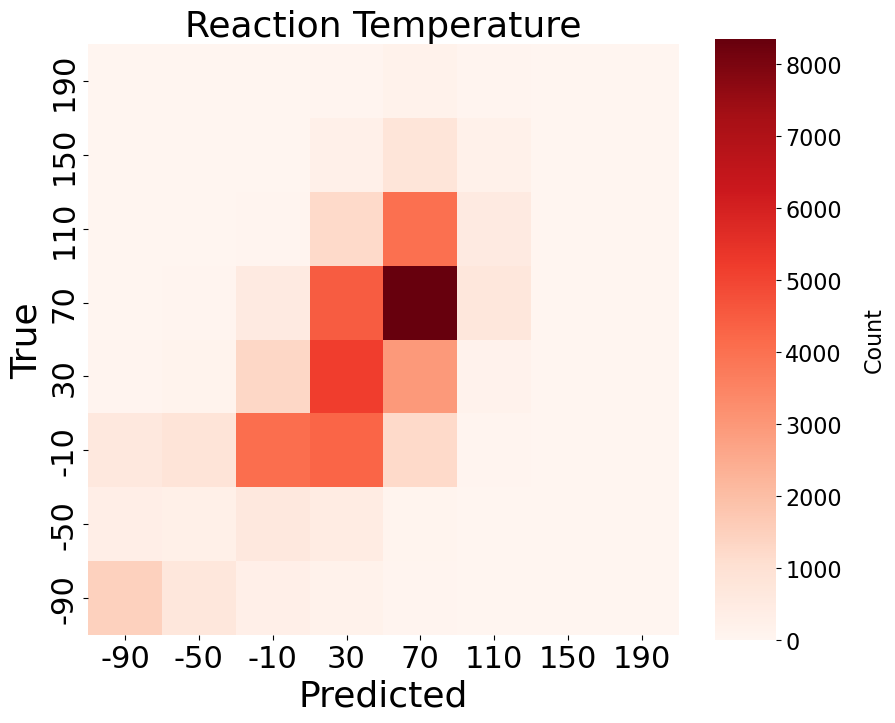

In [ ]:


# read_data
file_path = 'temp_yield_no_sig_graph.xlsx'
sheet_name = 'temp'
df = pd.read_excel(file_path, sheet_name=sheet_name, index_col=[0])


interval = 4
aggregated_df = aggregate_data(df, interval)


plt.figure(figsize=(9, 9))  

matrix_size = max(len(aggregated_df.columns), len(aggregated_df.index))


ax = sns.heatmap(
    aggregated_df, 
    annot=False, 
    cmap="Reds", 
    cbar=True,
    cbar_kws={
        'shrink': 0.7,  
        'aspect': 10,   
        'pad': 0.05     
    },
    xticklabels=[f"{int(label)}" for label in aggregated_df.columns],
    yticklabels=[f"{int(label)}" for label in aggregated_df.index],
    square=True  
)


ax.set_aspect('equal')  

ax.set_title('Reaction Temperature', fontsize=26)
ax.set_xlabel('Predicted', fontsize=26)
ax.set_ylabel('True', fontsize=26)

ax.tick_params(axis='both', which='major', labelsize=22)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Count', size=16, labelpad=15)

ax.invert_yaxis()

plt.tight_layout()

plt.show()

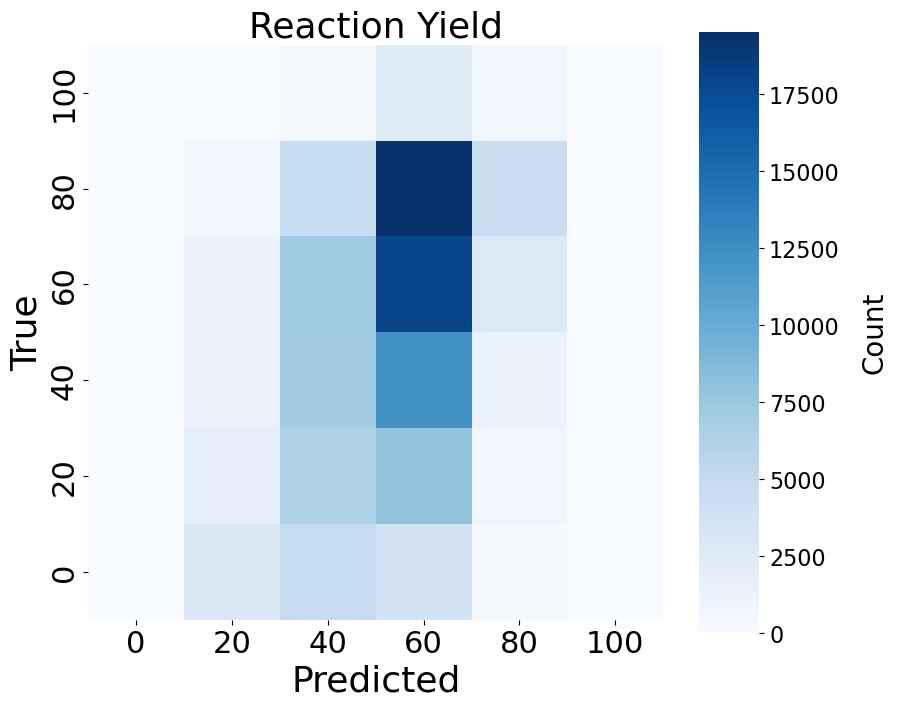

In [ ]:
file_path = 'temp_yield_no_sig_graph.xlsx'
sheet_name = 'yield' 

df = pd.read_excel(file_path, sheet_name=sheet_name, index_col=[0])


interval = 4
aggregated_df = aggregate_data(df, interval)

plt.figure(figsize=(9, 9))  

ax = sns.heatmap(
    aggregated_df, 
    annot=False, 
    cmap="Blues", 
    cbar=True,
    cbar_kws={
        'shrink': 0.7,  
        'aspect': 10,   
        'pad': 0.05     
    },
    square=True  
)

ax.set_title('Reaction Yield', fontsize=26)
ax.set_xlabel('Predicted', fontsize=26)
ax.set_ylabel('True', fontsize=26)

ax.tick_params(axis='both', which='major', labelsize=22)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Count', size=20, labelpad=15)

ax.invert_yaxis()

plt.tight_layout()

plt.show()

# molecule & reaction embedding

In [1]:
import os
import torch
import pickle
from torch.utils.data import Dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from rdkit import Chem
from ChemBart import CB_END
import argparse
import sys
import random
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from rdkit.RDLogger import DisableLog
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def set_seed(seed):
    """Set all possible random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class CB_END_Binary(CB_END):
    '''
    Inherited class for binary classification task.
    '''
    def __init__(self,
                 name: str, pre_model: str, device: str = "cuda:0",
                 ran: int = 0, out_type: int = 2):
        super().__init__(out_type, name, pre_model, device, ran)

    def transform(self, smiles_list):
        """
        Transform a list of SMILES strings into their corresponding output vectors.

        参数:
        - smiles_list: 一个包含 SMILES 字符串的列表

        返回:
        - outputs: 一个包含每个 SMILES 对应输出向量的列表
        """
        self.eval()
        self.to(self.device)
        outputs = []

        with torch.no_grad():
            for smile in smiles_list:
                # 将 SMILES 编码为输入张量
                inp = self.tokenizer.encoder(smile)
                out = inp.to(self.device)

                # 获取输出向量
                out = self.BartNN(input_ids=out, decoder_input_ids=out, return_dict=True, output_hidden_states=True).decoder_hidden_states[-1][0][-1]

                # 将输出向量添加到结果列表中
                outputs.append(out.cpu().numpy())

        return outputs
    
    def get_embeddings(self, smiles_list):
        """
        Transform a list of SMILES strings into their corresponding embeddings.

        参数:
        - smiles_list: 一个包含 SMILES 字符串的列表

        返回:
        - embeddings: 一个包含每个 SMILES 对应嵌入向量的列表
        """
        self.to(self.device)
        embeddings = []

        with torch.no_grad():
            for smile in smiles_list:
                # 将 SMILES 编码为输入张量
                inp = self.tokenizer.encoder(smile).to(self.device)

                # 获取嵌入向量
                embedding = self.BartNN.get_input_embeddings()(inp).squeeze(0)

                # 将嵌入向量添加到结果列表中
                embeddings.append(embedding.cpu().numpy())

        return embeddings
    
    def get_attention_matrix(self, smiles):
        self.eval()
        inputs = self.tokenizer.encoder(smiles)
        with torch.no_grad():
            outputs = self.BartNN(inputs, decoder_input_ids=inputs, output_attentions=True)
        #   outputs = self.BartNN(input_ids=inputs, decoder_input_ids=inputs, return_dict=True, output_hidden_states=True)
        # 获取最后一层编码器的注意力矩阵
        encoder_self_attention = outputs.encoder_attentions[-1]
        
        # 获取解码器的自注意力矩阵
        decoder_self_attentions = outputs.decoder_attentions[-1]

        # 获取交叉注意力矩阵
        cross_attentions = outputs.cross_attentions[-1]
        
        # 选择第一个样本的第一个头的注意力矩阵
        #attention_matrix = last_layer_attention[0, 0].detach().cpu().numpy()
        # 获取 token 列表
        tokens = self.tokenizer.encoder(smiles)        
        return encoder_self_attention,decoder_self_attentions,cross_attentions,tokens


[2025-08-12 19:30:29,953] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)


RDKit WARNING: [19:30:29] Enabling RDKit 2019.09.3 jupyter extensions
[19:30:29] Enabling RDKit 2019.09.3 jupyter extensions


 [WARNING]  Please specify the CUTLASS repo directory as environment variable $CUTLASS_PATH
 [WARNING]  please install triton==1.0.0 if you want to use sparse attention


pre-trained model ChemBart_model/ChemBart_MIT_6.pth


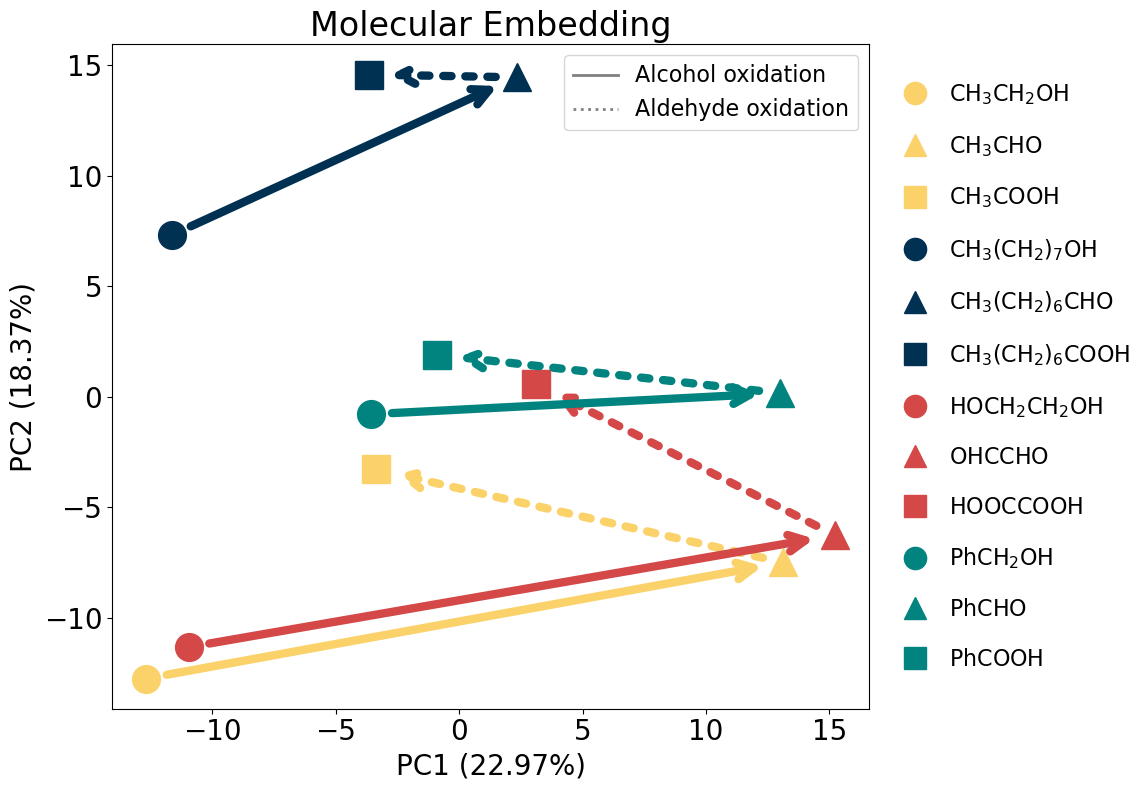

In [16]:
def draw(premodel_name):
    set_seed(42)
    model = CB_END_Binary(' ', premodel_name, "cuda:0")
    smiles_list = [
        'CCO', 'CC=O', 'CC(=O)-O',
        'CCCCCCCCO', 'CCCCCCCC=O', 'CCCCCCCC(=O)O',
        'OCCO', 'O=CC=O', 'OC(=O)C(=O)O',
        'OCc1ccccc1', 'O=Cc1ccccc1', 'O=C(O)c1ccccc1'
    ]
    
    molecular_list = [
        r'$\mathrm{CH_3CH_2OH}$', r'$\mathrm{CH_3CHO}$', r'$\mathrm{CH_3COOH}$',
        r'$\mathrm{CH_3(CH_2)_7OH}$', r'$\mathrm{CH_3(CH_2)_6CHO}$', r'$\mathrm{CH_3(CH_2)_6COOH}$',
        r'$\mathrm{HOCH_2CH_2OH}$', r'$\mathrm{OHCCHO}$', r'$\mathrm{HOOCCOOH}$',
        r'$\mathrm{PhCH_2OH}$', r'$\mathrm{PhCHO}$', r'$\mathrm{PhCOOH}$'
    ]
    
    emb = model.transform(smiles_list)
    
    # PCA降维
    pca = PCA(n_components=2)
    emb = pca.fit_transform(emb)
    emb[0][1] = emb[0][1] -1 
    emb[1][1] = emb[1][1] -1
    emb[2][1] = emb[2][1] -1
    # 创建画布和网格布局
    fig = plt.figure(figsize=(12, 8))  # 横向加宽画布
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])  # 左右比例3:1
    ax1 = fig.add_subplot(gs[0])  # 主绘图区
    ax2 = fig.add_subplot(gs[1])  # 图例区

    # 在主图区绘制
    color = [(251/255, 210/255, 106/255),(0/255, 49/255, 83/255),(212/255, 72/255, 72/255),(1/255, 132/255, 127/255)]
    markers = ['o', '^', 's']

    for i, (x, y) in enumerate(emb):
        ax1.plot(x, y, 
                marker=markers[i % 3], 
                color=color[i // 3], 
                markersize=20)

    # 主图样式设置
    ax1.set_title("Molecular Embedding", fontsize=24)
    ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)", fontsize=20)
    ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)", fontsize=20)
    ax1.tick_params(axis='both', labelsize=20)

    # 绘制箭头（保持原有代码，但使用ax1）
    for i in range(0, len(emb), 3):
        if i + 2 < len(emb):
            # 酒精氧化箭头
            ax1.annotate("", 
                       xy=(emb[i+1][0], emb[i+1][1]),
                       xytext=(emb[i][0], emb[i][1]),
                       arrowprops=dict(
                           arrowstyle="->",
                           color=color[i // 3],
                           linewidth=6,
                           shrinkA=15,
                           shrinkB=15,mutation_scale=30))
            # 醛氧化箭头
            ax1.annotate("",
                       xy=(emb[i+2][0], emb[i+2][1]),
                       xytext=(emb[i+1][0], emb[i+1][1]),
                       arrowprops=dict(
                           arrowstyle="->",
                           linestyle=':',
                           color=color[i // 3],
                           linewidth=6,
                           shrinkA=15,
                           shrinkB=15,mutation_scale=30))

    # 在右侧区域添加图例
    legend_elements = [
        plt.Line2D([0], [0], 
                  marker=markers[i%3], 
                  color=color[i//3], 
                  label=mol,
                  linestyle='None',
                  markersize=16) 
        for i, mol in enumerate(molecular_list)
    ]
    
    # 调整图例参数
    ax2.axis('off')  # 关闭坐标轴
    leg = ax2.legend(handles=legend_elements, 
                    loc='center left',
                    fontsize=16,
                    frameon=False,
                    handletextpad=0.5,
                    borderaxespad=0.,
                    labelspacing=1.2)
    
    # 添加箭头图例
    arrow_legend = ax1.legend(
        handles=[
            plt.Line2D([0], [0], color='gray', linestyle='-', linewidth=2, label='Alcohol oxidation'),
            plt.Line2D([0], [0], color='gray', linestyle=':', linewidth=2, label='Aldehyde oxidation')
        ],
        loc='upper right',
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

draw('ChemBart_MIT_6')

## element embedding

In [ ]:
import json
from rdkit import Chem
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# -------------------------------
# 1. 加载反应数据
# -------------------------------
with open('../data/50K/50K_DongLab/uspto50k.json', 'r', encoding='utf-8') as f:
    reaction_list = json.load(f)

print(f"✅ 共加载 {len(reaction_list)} 条反应")

# -------------------------------
# 2. 提取所有原子元素符号
# -------------------------------
atom_counter = Counter()

# 支持的常见元素（用于过滤异常或虚拟原子）
valid_elements = {'C', 'H', 'O', 'N', 'Cl', 'Br', 'F', 'I', 'S', 'P', 'B', 'Si', 
                  'Li', 'Na', 'K', 'Mg', 'Ca', 'Fe', 'Cu', 'Zn', 'Pd', 'Pt', 'Ni', 'Ru'}

valid_elements = {'H', 'He',
                  'Li','Be', 'B', 'C', 'N', 'O', 'F', 'Ne',
                  'Na','Mg','Al','Si', 'P', 'S', 'Cl', 'Ar',
                  'K', 'Ca', 'Sc','Ti','V','Cr','Mn','Fe','Co', 'Ni','Cu','Zn', 'Ga', 'Ge', 'As', 'Se','Br','Kr',
                  'Rb','Sr', 'Y', 'Zr','Nb','Mo','Tc','Ru','Rh','Pd','Ag','Cd', 'In', 'Sn', 'Sb', 'Te','I', 'Xe',
                  'Cs','Ba',      'Hf','Ta','W', 'Re','Os','Ir','Pt','Au','Hg', 'Tl', 'Pb', 'Po'
                  }

for idx, reaction_smiles in enumerate(reaction_list):
    try:
        # 分割反应物、试剂、产物（忽略中间部分也可以，我们关注所有原子）
        parts = reaction_smiles.split('>')
        all_smiles = []
        for part in parts:
            all_smiles.extend([s.strip() for s in part.split('.') if s.strip()])

        for smi in all_smiles:
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                continue  # 跳过无效SMILES
            for atom in mol.GetAtoms():
                symbol = atom.GetSymbol()
                # 可选：只保留感兴趣的元素
                if symbol in valid_elements:
                    atom_counter[symbol] += 1
    except Exception as e:
        print(f"Error processing reaction {idx}: {str(e)}")
        continue

print("\n📊 原子频次统计（前10）:")
for elem, count in atom_counter.most_common(10):
    print(f"{elem}: {count:,}")

# -------------------------------
# 3. 计算频率（百分比）
# -------------------------------
total_atoms = sum(atom_counter.values())
print(f"\n🧮 总原子数: {total_atoms:,}")

freq_data = {}
for elem, count in atom_counter.items():
    freq_data[elem] = count / total_atoms * 100

print("\n📈 元素频率（Top 10）:")
for elem, freq in sorted(freq_data.items(), key=lambda x: -x[1])[:10]:
    print(f"{elem}: {freq:.2f}%")

# -------------------------------
# 4. 可视化：柱状图
# -------------------------------
# 取前15个高频元素
top_elements = [elem for elem, _ in atom_counter.most_common(20)]
top_counts = [atom_counter[elem] for elem in top_elements]
top_labels = [f"{elem}\n({freq_data[elem]:.1f}%)" for elem in top_elements]

plt.figure(figsize=(12, 6))
sns.barplot(x=top_labels, y=top_counts, palette="viridis")
plt.yscale('log')  # 使用对数刻度，便于观察差异
plt.title("Top 15 Atoms in USPTO-50k Reactions", fontsize=16)
plt.ylabel("Log Count")
plt.xlabel("Atom (Frequency %)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
c = CB_END_Binary('test','ChemBart_MIT_6',"cuda:2")

使用 NumPy 计算的欧氏距离矩阵:
[[0.00069 0.92552 1.10797 1.08587 1.11212 1.09727 1.08655 1.09736 1.12407]
 [0.92552 0.00069 1.14002 1.08483 1.14287 1.05621 1.06784 1.05430 1.16104]
 [1.10797 1.14002 0.00069 1.18121 1.17912 1.19543 1.15916 1.17897 1.22104]
 [1.08587 1.08483 1.18121 0.00055 1.10164 0.95391 1.02721 0.91672 1.11462]
 [1.11212 1.14287 1.17912 1.10164 0.00077 1.13427 1.01628 1.09192 1.12505]
 [1.09727 1.05621 1.19543 0.95391 1.13427 0.00060 1.06174 0.97087 1.16706]
 [1.08655 1.06784 1.15916 1.02721 1.01628 1.06174 0.00069 0.99936 1.06139]
 [1.09736 1.05430 1.17897 0.91672 1.09192 0.97087 0.99936 0.00060 1.09502]
 [1.12407 1.16104 1.22104 1.11462 1.12505 1.16706 1.06139 1.09502 0.00077]]


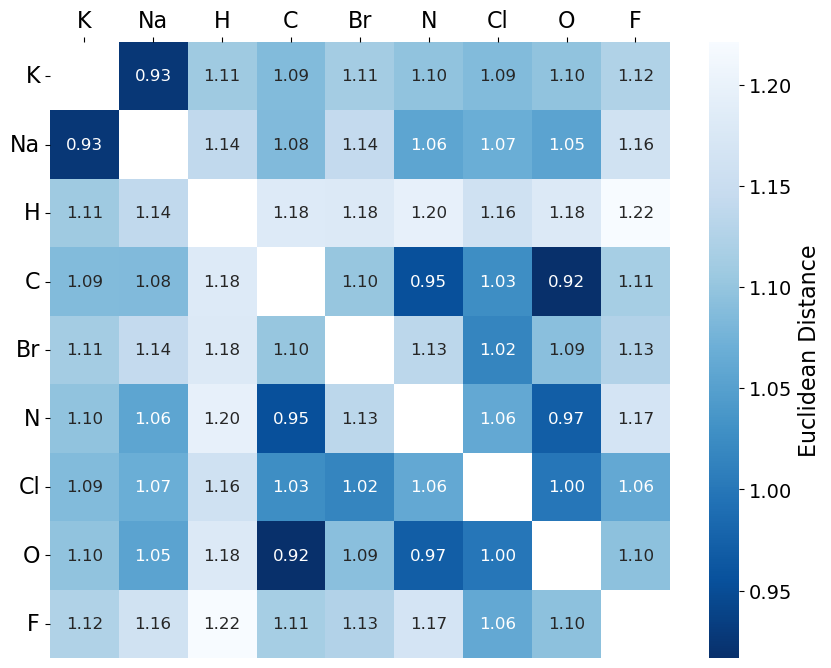

In [ ]:
atoms_list = ['K', 'Na', 'H', 'C', 'Br', 'N', 'Cl', 'O', 'F']

emb_end = model.get_embeddings(atoms_list)
emb_ends = []
for i in emb_end:
    #去除开头和结尾编码
    emb_ends.append(i[1])
matrix = np.stack(emb_ends)
matrix.shape

def euclidean_distance_matrix_np(vectors):
    """
    使用 NumPy 的广播和向量化操作计算一组向量之间的欧氏距离矩阵。

    参数:
    - vectors: 形状为 (n, d) 的二维数组，其中 n 是向量的数量，d 是向量的维度

    返回:
    - distance_matrix: 形状为 (n, n) 的二维数组，表示每对向量之间的欧氏距离
    """
    n = vectors.shape[0]
    vectors_squared = np.sum(vectors**2, axis=1, keepdims=True)
    distances = np.sqrt(vectors_squared + vectors_squared.T - 2 * np.dot(vectors, vectors.T))
    return distances

# 计算欧氏距离矩阵
distance_matrix_np = euclidean_distance_matrix_np(matrix)
# 设置打印选项，保留五位有效数字
np.set_printoptions(precision=5, suppress=True, floatmode='fixed')
# 打印距离矩阵
print("使用 NumPy 计算的欧氏距离矩阵:")
print(distance_matrix_np)

# 将对角线的值设置为0
np.fill_diagonal(distance_matrix_np, None)

# 设置打印选项，保留五位有效数字
np.set_printoptions(precision=5, suppress=True, floatmode='fixed')

# 打印距离矩阵
#print("使用 NumPy 计算的欧氏距离矩阵:")
#print(distance_matrix_np)

# 创建热力图
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix_np, annot=True, fmt=".2f", cmap="Blues_r", 
            xticklabels=atoms_list, yticklabels=atoms_list, 
            cbar_kws={'label': 'Euclidean Distance'},
            annot_kws={'size': 12}
            )
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Euclidean Distance', size=16)
# 将横坐标放到图片上方
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# 设置标题和标签
#plt.title("Euclidean Distance Matrix for Different Atoms")
# 调整 y 轴标签的字体方向
ax.tick_params(axis='y', rotation=0)  # 将 y 轴标签的字体方向设置为水平
# 保存为矢量图
# 设置横纵坐标标签的字体大小
ax.tick_params(axis='both', which='major', labelsize=16)
# 显示热力图
plt.show()

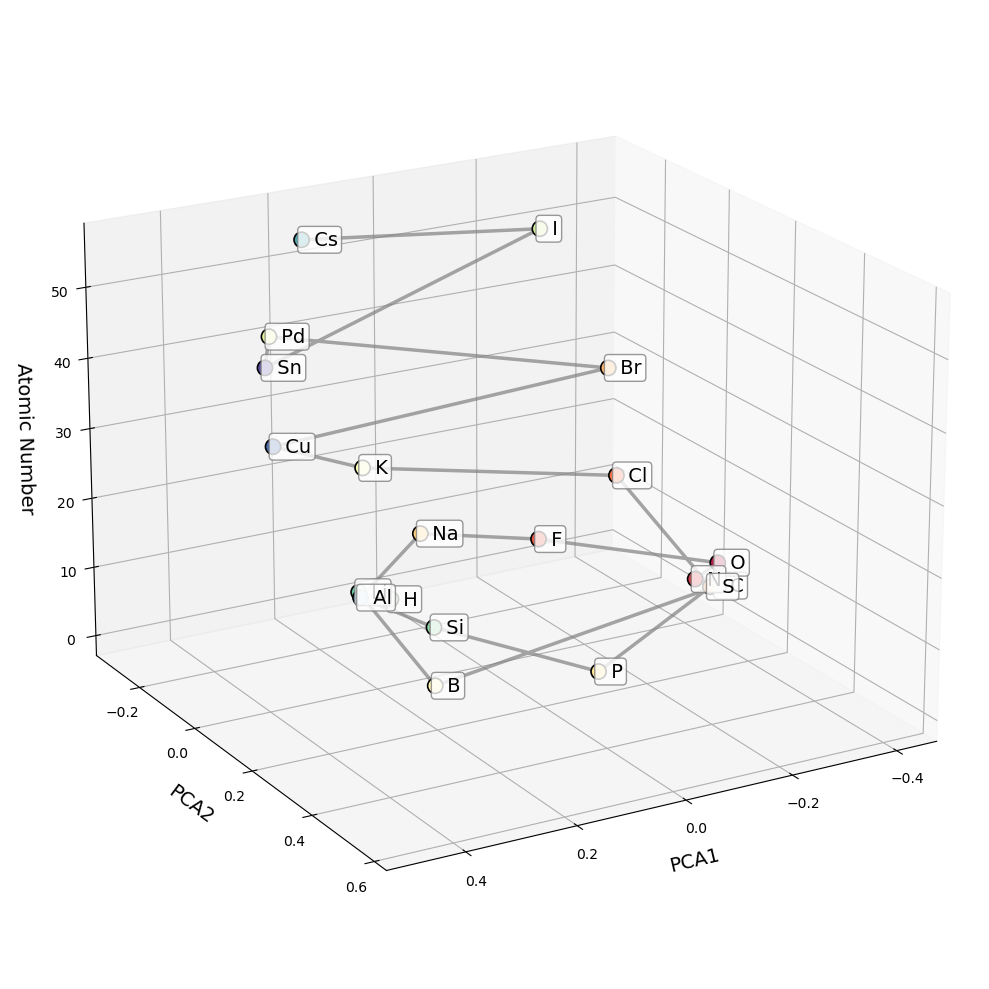

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import seaborn as sns

# ================================
# 1. 数据准备（同前）
# ================================
#atoms = ['Li','C','B', 'N', 'O', 'F', 'Na', 'Cl', 'K', 'Br']

atoms = ['C','O','N','F','Cl','S','Br','Na','P','B','K','Pd','I','H','Si','Li','Cs','Al','Cu','Sn']

atomic_numbers = {
    'H': 1,   'He': 2,
    'Li': 3,  'Be': 4,  'B': 5,   'C': 6,   'N': 7,   'O': 8,   'F': 9,
    'Na': 11, 'Mg': 12, 'Al': 13, 'Si': 14, 'P': 15,  'S': 16, 'Cl': 17,
    'K': 19,  'Ca': 20, 'Cu':29, 'Br': 35,
    'Pd':46, 'Sn':50 ,'I': 53,
    'Cs':55
}

# 假设 matrix 是你的 embedding 矩阵 (n_atoms, dim)
emb_end = model.get_embeddings(atoms)
emb_ends = []
for i in emb_end:
    #去除开头和结尾编码
    emb_ends.append(i[1])
matrix = np.stack(emb_ends)

pca = PCA(n_components=2)
xy_coords = pca.fit_transform(matrix)
x_coords = xy_coords[:, 0]
y_coords = xy_coords[:, 1]
z_values = [atomic_numbers[atom] for atom in atoms]

# ================================
# 2. 创建 3D 图并优化标注
# ================================
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 使用颜色区分
colors = plt.cm.Spectral(np.linspace(0, 1, len(atoms)))

# 绘制散点（加大 size，加边框）
scatter = ax.scatter(x_coords, y_coords, z_values,
                    c=colors, s=120, edgecolors='black', linewidth=1.2, depthshade=False)

# -------------------------------
# ✅ 改进标注：让标签清晰可见
# -------------------------------

# 调整：避免标签重叠 + 更大字体 + 白色背景框
for i, atom in enumerate(atoms):
    ax.text(x_coords[i], y_coords[i], z_values[i],
            f"  {atom}",
            fontsize=14,
            ha='left', va='center',
            bbox=dict(boxstyle="round,pad=0.2",
                      facecolor='white',
                      edgecolor='gray',
                      alpha=0.8),
            zorder=10)                      # 提高层级，确保在最上层

# -------------------------------
# ✅ 新增：按原子序数排序并连线
# -------------------------------
points = list(zip(x_coords, y_coords, z_values, atoms, colors))
points_sorted = sorted(points, key=lambda x: x[2])  # 按原子序数升序

xs_line = [p[0] for p in points_sorted]
ys_line = [p[1] for p in points_sorted]
zs_line = [p[2] for p in points_sorted]

ax.plot(xs_line, ys_line, zs_line,
        color='gray', linewidth=2.5, alpha=0.7, linestyle='-', 
        marker='o', markersize=4, markerfacecolor='w', markeredgewidth=1.5,
        label='Sequence by Atomic Number (Z)')
# -------------------------------
# 3. 设置坐标轴和标题
# -------------------------------
ax.set_xlabel('\nPCA1', fontsize=14, linespacing=1)
ax.set_ylabel('\nPCA2', fontsize=14, linespacing=1)
ax.set_zlabel('\nAtomic Number', fontsize=14, linespacing=1)
#ax.set_title("3D Atom Embedding Visualization\nWith Clear Labels", fontsize=16, pad=30)

# -------------------------------
# 4. 调整视角（关键！避免重叠）
# -------------------------------
ax.view_init(elev=20, azim=60)  # 尝试不同角度：elev=仰角, azim=旋转角
# 常用组合：
#   elev=20, azim=30   → 前侧视角
#   elev=30, azim=120  → 侧面视角
#   elev=90, azim=0    → 俯视图（只看 x-y）
#   elev=0, azim=0     → 侧视图（只看 x-z）

# -------------------------------
# 5. 美化布局
# -------------------------------
plt.tight_layout()
plt.show()

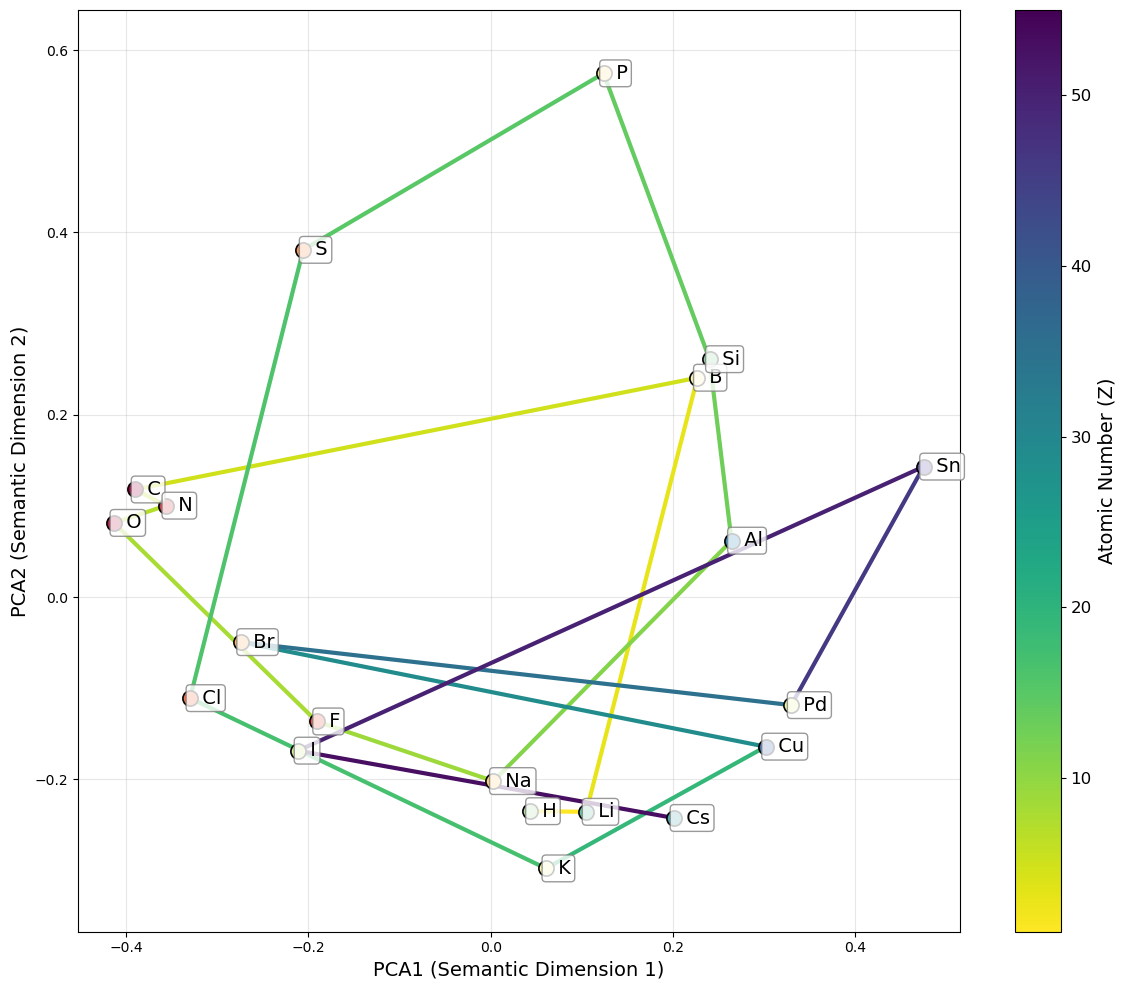

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

# -------------------------------
# 1. 准备数据
# -------------------------------
points = list(zip(x_coords, y_coords, z_values, atoms))
points_sorted = sorted(points, key=lambda x: x[2])  # 按原子序数升序

xs = [p[0] for p in points_sorted]
ys = [p[1] for p in points_sorted]
zs = [p[2] for p in points_sorted]

# 创建线段：每两个点之间是一条线段
points_2d = np.array([xs, ys]).T.reshape(-1, 1, 2)
segments = np.concatenate([points_2d[:-1], points_2d[1:]], axis=1)

# 创建 LineCollection
lc = LineCollection(segments, cmap='viridis_r', linewidth=3)
lc.set_array(zs)  # 颜色映射到原子序数

# -------------------------------
# 2. 绘制
# -------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# 添加渐变色折线
line = ax.add_collection(lc)

# 绘制散点（保持原色）
for i, atom in enumerate(atoms):
    idx_in_sorted = [j for j, p in enumerate(points_sorted) if p[3] == atom][0]
    ax.scatter(x_coords[i], y_coords[i],
               c=[plt.cm.Spectral(np.linspace(0, 1, len(atoms)))[i]], 
               s=120, edgecolors='black', linewidth=1.2, zorder=5)

# 添加标签
for i, atom in enumerate(atoms):
    ax.text(x_coords[i], y_coords[i],
            f"  {atom}",
            fontsize=14, ha='left', va='center',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', edgecolor='gray', alpha=0.8),
            zorder=10)

# 颜色条
cbar = plt.colorbar(line, ax=ax)
cbar.set_label('Atomic Number (Z)', size=14)
cbar.ax.tick_params(labelsize=12)

# 设置坐标轴
ax.set_xlabel('PCA1 (Semantic Dimension 1)', fontsize=14)
ax.set_ylabel('PCA2 (Semantic Dimension 2)', fontsize=14)
#ax.set_title('Atom Embedding Path with Gradient Color\n(Color = Increasing Atomic Number)', fontsize=16)

ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()

## attention matrix

In [ ]:
c = CB_END_Binary('test','ChemBart_MIT_6',"cuda:2")

pre-trained model ChemBart_model/ChemBart_MIT_6.pth


In [ ]:
# CCCCCCBr.[Br-].[Mg+2].[c-]1ccccc1>CCOCC>CCCCCCc1ccccc1.[Mg+2].[Br-].[Br-]
# 反应物本身注意力矩阵'CCCCCCBr.[Br-].[Mg+2].[c-]1ccccc1>CCOCC><msk>'
# 反应物和生成物之间注意力CCCCCCBr.[Br-].[Mg+2].[c-]1ccccc1 和 CCCCCCc1ccccc1.[Mg+2].[Br-].[Br-]

encoder_self_attentions, decoder_self_attentions, cross_attentions, tokens = c.get_attention_matrix('CCCCCCBr.[Br-].[Mg+2].[c-]1ccccc1>CCOCC><msk>')

#c.visualize_attention_matrix('CCCCCCBr.[Br-].[Mg+2].[c-]1ccccc1>CCOCC><msk>')
# 打印 tokens
print("Tokens:")
print(tokens)
print(len(tokens[0]))

Tokens:
tensor([[  1, 118, 118, 118, 118, 118, 118, 147,  11,   6, 147,  10,   7,  11,
           6, 124,   9,  20,   7,  11,   6, 108,  10,   7,  19, 108, 108, 108,
         108, 108,  19,   2, 118, 118, 120, 118, 118,   2,   4,   3]])
40


In [ ]:
# CCCCCCBr.[Br-].[Mg+2].[c-]1ccccc1>CCOCC>CCCCCCc1ccccc1.[Mg+2].[Br-].[Br-]
# 反应物本身注意力矩阵'CCCCCCBr.[Br-].[Mg+2].[c-]1ccccc1>CCOCC><msk>'
# 反应物和生成物之间注意力CCCCCCBr.[Br-].[Mg+2].[c-]1ccccc1 和 CCCCCCc1ccccc1.[Mg+2].[Br-].[Br-]
encoder_self_attentions, decoder_self_attentions, cross_attentions, tokens = c.get_attention_matrix('CCCCCCBr.[Br-].[Mg+2].[c-]1ccccc1>CCOCC><msk>')
# 字符标签
smiles_chars = ['<c>','C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'Br', '.', '[', 'Br', '-', ']', '.', '[', 'Mg', '+', '2', ']', '.', '[', 'c', '-', ']', '1', 'c', 'c', 'c', 'c', 'c', '1', '>', 'C', 'C', 'O', 'C', 'C', '>', '<m>','E']
#选择注意力矩阵
    
def hot_plot1(i=0, attention_type='decoder'):
    if attention_type == 'encoder':
        attentions_np = encoder_self_attentions[0][i].detach().cpu().numpy()
    elif attention_type == 'decoder':
        attentions_np = decoder_self_attentions[0][i].detach().cpu().numpy()
    elif attention_type == 'cross':
        attentions_np = cross_attentions[0][i].detach().cpu().numpy()
    else:
        raise ValueError("attention_type must be 'encoder', 'decoder', or 'cross'")

    # 创建热力图
    plt.figure(figsize=(10, 8))
    sns.heatmap(attentions_np, annot=False, fmt=".3f", cmap="Blues", 
                xticklabels=smiles_chars, yticklabels=smiles_chars, 
                cbar_kws={'label': 'Attention Value'})

    # 将横坐标放到图片上方
    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # 设置标题和标签
    #plt.title("Euclidean Distance Matrix for Different Atoms")
    # 设置横纵坐标标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=7)
    # 显示热力图
    plt.show()


In [ ]:
def hot_plot2(i=0, attention_type='decoder'):
    if attention_type == 'encoder':
        attentions_np = encoder_self_attentions[0][i].detach().cpu().numpy()
    elif attention_type == 'decoder':
        attentions_np = decoder_self_attentions[0][i].detach().cpu().numpy()
    elif attention_type == 'cross':
        attentions_np = cross_attentions[0][i].detach().cpu().numpy()
    else:
        raise ValueError("attention_type must be 'encoder', 'decoder', or 'cross'")
    # position
    reactant_start =  1
    reactant_end = 8
    reagent_start = 7
    reagent_end = 8

    #attentions_np = decoder_self_attentions[0][i].detach().cpu().numpy()
    reactant_product_attention = attentions_np[reagent_start:reagent_end, reactant_start:reactant_end]
    #create hot map
    plt.figure(figsize=(10, 3))
    sns.heatmap(reactant_product_attention, annot=False, fmt=".3f", cmap="Blues", 
                xticklabels=smiles_chars[reactant_start:reactant_end], yticklabels=smiles_chars[reagent_start:reagent_end], 
                cbar_kws={'label': 'Attention Value'},
                square=True)

    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    # 调整 y 轴标签的字体方向
    ax.tick_params(axis='y', rotation=0)  # 将 y 轴标签的字体方向设置为水平
    # 设置标题和标签
    #plt.title("Euclidean Distance Matrix for Different Atoms")
    # 设置横纵坐标标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=10)
    #cbar = ax.collections[0].colorbar
    #cbar.ax.tick_params(labelsize=10)
    #cbar.set_label('Attention Value', size=10)
    # 调整颜色条的大小
    #cbar.ax.set_aspect(100)  # 调整颜色条的宽高比
    #cbar.ax.set_position([0.92, 0.15, 0.03, 0.7])  # 调整颜色条的位置和大小
    # 将横坐标放到图片上方
    # 显示热力图
    plt.show()

In [ ]:
def hot_plot3(i=0, attention_type='decoder'):
    if attention_type == 'encoder':
        attentions_np = encoder_self_attentions[0][i].detach().cpu().numpy()
    elif attention_type == 'decoder':
        attentions_np = decoder_self_attentions[0][i].detach().cpu().numpy()
    elif attention_type == 'cross':
        attentions_np = cross_attentions[0][i].detach().cpu().numpy()
    else:
        raise ValueError("attention_type must be 'encoder', 'decoder', or 'cross'")
    # 获取反应物和生成物之间的注意力值矩阵区域
    reactant_start =  1
    reactant_end = 8
    reagent_start = 21
    reagent_end = 23

    #attentions_np = decoder_self_attentions[0][i].detach().cpu().numpy()
    reactant_product_attention = attentions_np[reagent_start:reagent_end, reactant_start:reactant_end]

    # 计算列上的平均值
    reactant_product_attention_mean = np.mean(reactant_product_attention, axis=0).reshape(1, -1)

    # 创建热力图
    plt.figure(figsize=(10, 3))
    sns.heatmap(reactant_product_attention_mean, annot=False, fmt=".3f", cmap="Blues", 
                xticklabels=smiles_chars[reactant_start:reactant_end], 
                #yticklabels=smiles_chars[reagent_start:reagent_end], 
                yticklabels=[r'$C^-$'],
                cbar_kws={'label': 'Attention Value'},
                square=True)

    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    # 调整 y 轴标签的字体方向
    ax.tick_params(axis='y', rotation=0)  # 将 y 轴标签的字体方向设置为水平
    # 设置标题和标签
    #plt.title("Euclidean Distance Matrix for Different Atoms")
    # 设置横纵坐标标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=10)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Attention Value', size=10)
    # 调整颜色条的大小
    #cbar.ax.set_aspect(100)  # 调整颜色条的宽高比
    #cbar.ax.set_position([0.92, 0.15, 0.03, 0.7])  # 调整颜色条的位置和大小
    # 将横坐标放到图片上方
    # 显示热力图
    plt.show()

In [ ]:
def hot_plot4(i=0, attention_type='decoder'):
    if attention_type == 'encoder':
        attentions_np = encoder_self_attentions[0][i].detach().cpu().numpy()
    elif attention_type == 'decoder':
        attentions_np = decoder_self_attentions[0][i].detach().cpu().numpy()
    elif attention_type == 'cross':
        attentions_np = cross_attentions[0][i].detach().cpu().numpy()
    else:
        raise ValueError("attention_type must be 'encoder', 'decoder', or 'cross'")
    # 获取反应物和生成物之间的注意力值矩阵区域
    reactant_start =  1
    reactant_end = 19
    reagent_start = 21
    reagent_end = 23

    #attentions_np = decoder_self_attentions[0][i].detach().cpu().numpy()
    reactant_product_attention = attentions_np[reagent_start:reagent_end, reactant_start:reactant_end]
    # 创建热力图
    plt.figure(figsize=(10, 3))
    sns.heatmap(reactant_product_attention, annot=False, fmt=".3f", cmap="Blues", 
                xticklabels=smiles_chars[reactant_start:reactant_end], 
                yticklabels=smiles_chars[reagent_start:reagent_end], 
                cbar_kws={'label': 'Attention Value'},
                square=True)

    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    # 调整 y 轴标签的字体方向
    ax.tick_params(axis='y', rotation=0)  # 将 y 轴标签的字体方向设置为水平
    # 设置标题和标签
    #plt.title("Euclidean Distance Matrix for Different Atoms")
    # 设置横纵坐标标签的字体大小
    ax.tick_params(axis='both', which='major', labelsize=10)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Attention Value', size=10)
    # 调整颜色条的大小
    #cbar.ax.set_aspect(100)  # 调整颜色条的宽高比
    #cbar.ax.set_position([0.92, 0.15, 0.03, 0.7])  # 调整颜色条的位置和大小
    # 将横坐标放到图片上方
    # 显示热力图
    plt.show()

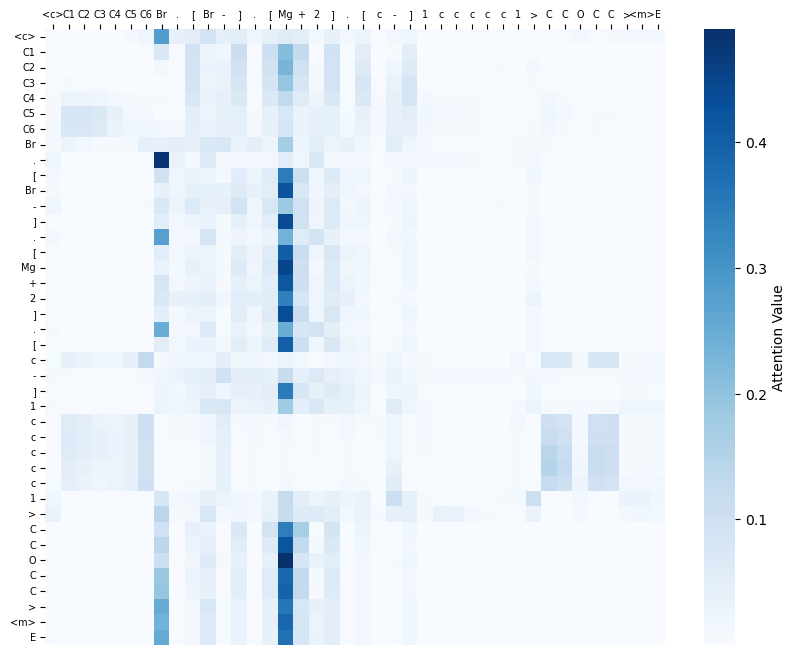

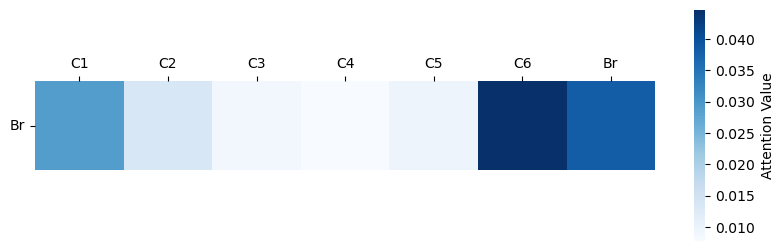

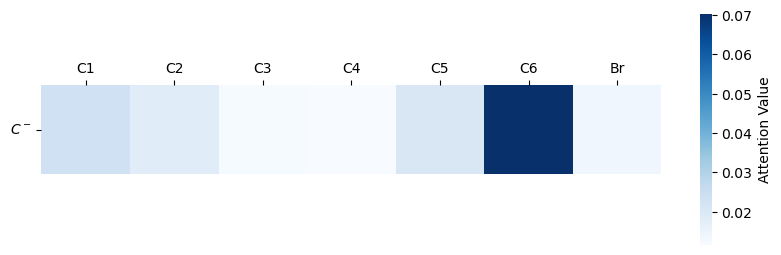

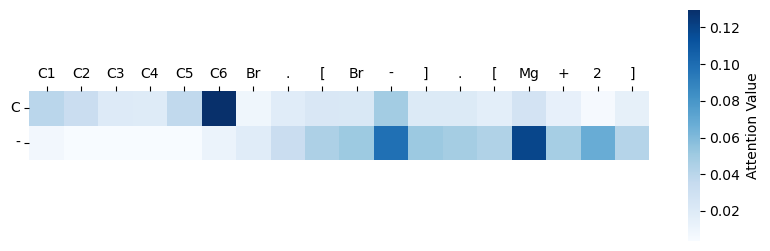

In [ ]:
i = 14
type = "encoder"
hot_plot1(i,type)
hot_plot2(i,type)
hot_plot3(i,type)
hot_plot4(i,type)